In [ ]:
from google.colab import files

print("Upload 5 files one by one:")
print("1. campaigns.csv")
print("2. customers.csv")
print("3. events.csv")
print("4. products.csv")
print("5. transactions.csv")

uploaded = files.upload()

Upload 5 files one by one:
1. campaigns.csv
2. customers.csv
3. events.csv
4. products.csv
5. transactions.csv


Saving campaigns.csv to campaigns (1).csv
Saving customers.csv to customers (1).csv
Saving events.csv to events (1).csv
Saving products.csv to products (1).csv
Saving transactions.csv to transactions (1).csv


In [ ]:
import os
print("Files in Colab:")
for f in os.listdir():
    if f.endswith('.csv'):
        print(f"✅ {f}")

Files in Colab:
✅ transactions (1).csv
✅ events (1).csv
✅ customers.csv
✅ products (1).csv
✅ campaigns (1).csv
✅ events.csv
✅ campaigns.csv
✅ transactions.csv
✅ customers (1).csv
✅ products.csv


In [ ]:
# Import semua library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

print("="*60)
print("LOAD ALL TABLES")
print("="*60)

# Load each CSV file
campaigns = pd.read_csv('campaigns.csv')
customers = pd.read_csv('customers.csv')
events = pd.read_csv('events.csv')
products = pd.read_csv('products.csv')
transactions = pd.read_csv('transactions.csv')

print("\n✅ All tables loaded successfully!")
print(f"\n📊 campaigns: {len(campaigns):,} rows, {len(campaigns.columns)} columns")
print(f"📊 customers: {len(customers):,} rows, {len(customers.columns)} columns")
print(f"📊 events: {len(events):,} rows, {len(events.columns)} columns")
print(f"📊 products: {len(products):,} rows, {len(products.columns)} columns")
print(f"📊 transactions: {len(transactions):,} rows, {len(transactions.columns)} columns")

# Preview first 3 rows of each table
print("\n" + "="*60)
print("PREVIEW: campaigns.csv")
print("="*60)
print(campaigns.head(3))

print("\n" + "="*60)
print("PREVIEW: customers.csv")
print("="*60)
print(customers.head(3))

print("\n" + "="*60)
print("PREVIEW: events.csv")
print("="*60)
print(events.head(3))

print("\n" + "="*60)
print("PREVIEW: products.csv")
print("="*60)
print(products.head(3))

print("\n" + "="*60)
print("PREVIEW: transactions.csv")
print("="*60)
print(transactions.head(3))

LOAD ALL TABLES

✅ All tables loaded successfully!

📊 campaigns: 50 rows, 7 columns
📊 customers: 100,000 rows, 7 columns
📊 events: 2,000,000 rows, 12 columns
📊 products: 2,000 rows, 6 columns
📊 transactions: 103,127 rows, 9 columns

PREVIEW: campaigns.csv
   campaign_id      channel     objective  start_date    end_date  \
0            1  Paid Search    Cross-sell  2021-10-25  2021-11-26   
1            2        Email     Retention  2021-10-24  2021-12-24   
2            3        Email  Reactivation  2023-10-08  2023-11-30   

  target_segment  expected_uplift  
0   Deal Seekers            0.022  
1   Deal Seekers            0.116  
2     Churn Risk            0.100  

PREVIEW: customers.csv
   customer_id signup_date country  age  gender loyalty_tier  \
0            1  2021-04-08      BR   48    Male       Bronze   
1            2  2023-04-28      IN   36  Female       Silver   
2            3  2022-12-18      UK   35  Female       Silver   

  acquisition_channel  
0            Refer

In [ ]:
print("="*60)
print("DEEP DATA CLEANING")
print("="*60)

# Function to check data quality
def check_data_quality(df, name):
    print(f"\n{'='*50}")
    print(f"TABLE: {name}")
    print(f"{'='*50}")

    # 1. Basic info
    print(f"\n📌 Shape: {df.shape[0]:,} rows, {df.shape[1]} columns")

    # 2. Missing values
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    missing_cols = missing[missing > 0]
    if len(missing_cols) > 0:
        print(f"\n⚠️ Missing Values found:")
        for col, val in missing_cols.items():
            print(f"   - {col}: {val:,} missing ({missing_pct[col]:.1f}%)")
    else:
        print(f"\n✅ No missing values found!")

    # 3. Duplicates
    dup_count = df.duplicated().sum()
    if dup_count > 0:
        print(f"\n⚠️ Duplicate rows: {dup_count:,}")
    else:
        print(f"\n✅ No duplicate rows found!")

    # 4. Data types
    print(f"\n📌 Data types:")
    for col, dtype in df.dtypes.items():
        print(f"   - {col}: {dtype}")

    return missing_cols

# Check each table
print("\n🔍 RUNNING DATA QUALITY CHECKS...")
print("="*60)

campaigns_missing = check_data_quality(campaigns, "campaigns")
customers_missing = check_data_quality(customers, "customers")
events_missing = check_data_quality(events, "events")
products_missing = check_data_quality(products, "products")
transactions_missing = check_data_quality(transactions, "transactions")

DEEP DATA CLEANING

🔍 RUNNING DATA QUALITY CHECKS...

TABLE: campaigns

📌 Shape: 50 rows, 7 columns

✅ No missing values found!

✅ No duplicate rows found!

📌 Data types:
   - campaign_id: int64
   - channel: object
   - objective: object
   - start_date: object
   - end_date: object
   - target_segment: object
   - expected_uplift: float64

TABLE: customers

📌 Shape: 100,000 rows, 7 columns

✅ No missing values found!

✅ No duplicate rows found!

📌 Data types:
   - customer_id: int64
   - signup_date: object
   - country: object
   - age: int64
   - gender: object
   - loyalty_tier: object
   - acquisition_channel: object

TABLE: events

📌 Shape: 2,000,000 rows, 12 columns

⚠️ Missing Values found:
   - product_id: 200,371 missing (10.0%)
   - device_type: 40,300 missing (2.0%)

✅ No duplicate rows found!

📌 Data types:
   - event_id: int64
   - timestamp: object
   - customer_id: int64
   - session_id: int64
   - event_type: object
   - product_id: float64
   - device_type: object
  

In [ ]:
print("="*60)
print("FIX MISSING VALUES")
print("="*60)

# Track changes
changes = {}

# 1. FIX events table
print("\n🔧 Fixing events table...")
original_len = len(events)

# Fill missing product_id with 0 (unknown product)
events['product_id'] = events['product_id'].fillna(0)
# Fill missing device_type with 'Unknown'
events['device_type'] = events['device_type'].fillna('Unknown')

missing_after = events.isnull().sum().sum()
changes['events'] = f"Fixed {original_len - len(events)} rows, filled 200,371 missing product_id, 40,300 missing device_type"

print(f"   ✅ events: {len(events):,} rows, missing values now: {missing_after}")

# 2. FIX transactions table
print("\n🔧 Fixing transactions table...")
original_len = len(transactions)

# Fill missing product_id with 0
transactions['product_id'] = transactions['product_id'].fillna(0)
# Fill missing gross_revenue with 0 (no revenue means no transaction)
transactions['gross_revenue'] = transactions['gross_revenue'].fillna(0)

missing_after = transactions.isnull().sum().sum()
changes['transactions'] = f"Fixed {original_len - len(transactions)} rows, filled 10,449 missing product_id, 10,449 missing gross_revenue"

print(f"   ✅ transactions: {len(transactions):,} rows, missing values now: {missing_after}")

# 3. Convert date columns to datetime
print("\n🔧 Converting date columns to datetime...")

# campaigns table
campaigns['start_date'] = pd.to_datetime(campaigns['start_date'])
campaigns['end_date'] = pd.to_datetime(campaigns['end_date'])
print(f"   ✅ campaigns: start_date, end_date converted")

# customers table
customers['signup_date'] = pd.to_datetime(customers['signup_date'])
print(f"   ✅ customers: signup_date converted")

# events table
events['timestamp'] = pd.to_datetime(events['timestamp'])
print(f"   ✅ events: timestamp converted")

# transactions table
transactions['timestamp'] = pd.to_datetime(transactions['timestamp'])
print(f"   ✅ transactions: timestamp converted")

# products table
products['launch_date'] = pd.to_datetime(products['launch_date'])
print(f"   ✅ products: launch_date converted")

print("\n" + "="*60)
print("FIXES APPLIED:")
print("="*60)
for key, value in changes.items():
    print(f"✅ {key}: {value}")

FIX MISSING VALUES

🔧 Fixing events table...
   ✅ events: 2,000,000 rows, missing values now: 0

🔧 Fixing transactions table...
   ✅ transactions: 103,127 rows, missing values now: 0

🔧 Converting date columns to datetime...
   ✅ campaigns: start_date, end_date converted
   ✅ customers: signup_date converted
   ✅ events: timestamp converted
   ✅ transactions: timestamp converted
   ✅ products: launch_date converted

FIXES APPLIED:
✅ events: Fixed 0 rows, filled 200,371 missing product_id, 40,300 missing device_type
✅ transactions: Fixed 0 rows, filled 10,449 missing product_id, 10,449 missing gross_revenue


In [ ]:
print("="*60)
print("FINAL VERIFICATION")
print("="*60)

# Function to verify clean data
def verify_clean(df, name):
    print(f"\n📌 {name}:")
    print(f"   - Rows: {len(df):,}")
    print(f"   - Missing values: {df.isnull().sum().sum()}")
    print(f"   - Duplicates: {df.duplicated().sum()}")

    # Show date range for timestamp columns
    if 'timestamp' in df.columns:
        print(f"   - Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
    if 'start_date' in df.columns:
        print(f"   - Campaign period: {df['start_date'].min()} to {df['end_date'].max()}")

print("FINAL DATA QUALITY REPORT")
print("="*60)

verify_clean(campaigns, "campaigns")
verify_clean(customers, "customers")
verify_clean(events, "events")
verify_clean(products, "products")
verify_clean(transactions, "transactions")

print("\n" + "="*60)
print("✅ DEEP DATA CLEANING COMPLETE!")
print("="*60)
print("\n📊 FINAL SUMMARY:")
print(f"   - campaigns: {len(campaigns):,} rows")
print(f"   - customers: {len(customers):,} rows")
print(f"   - events: {len(events):,} rows")
print(f"   - products: {len(products):,} rows")
print(f"   - transactions: {len(transactions):,} rows")

FINAL VERIFICATION
FINAL DATA QUALITY REPORT

📌 campaigns:
   - Rows: 50
   - Missing values: 0
   - Duplicates: 0
   - Campaign period: 2021-01-20 00:00:00 to 2024-01-06 00:00:00

📌 customers:
   - Rows: 100,000
   - Missing values: 0
   - Duplicates: 0

📌 events:
   - Rows: 2,000,000
   - Missing values: 0
   - Duplicates: 0
   - Date range: 2021-01-01 00:01:28 to 2023-12-31 23:57:50

📌 products:
   - Rows: 2,000
   - Missing values: 0
   - Duplicates: 0

📌 transactions:
   - Rows: 103,127
   - Missing values: 0
   - Duplicates: 0
   - Date range: 2021-01-01 00:12:50 to 2023-12-31 22:37:32

✅ DEEP DATA CLEANING COMPLETE!

📊 FINAL SUMMARY:
   - campaigns: 50 rows
   - customers: 100,000 rows
   - events: 2,000,000 rows
   - products: 2,000 rows
   - transactions: 103,127 rows


MARKETING CHANNEL ROI

📊 REVENUE BY MARKETING CHANNEL:
             total_revenue  avg_revenue  transaction_count  total_transactions
channel                                                                       
Affiliate       1608144.17        81.66              19694               19694
Paid Search     1533909.64        81.41              18841               18841
Email           1357550.66        81.09              16741               16741
Display         1211416.38        80.79              14995               14995
Social           972825.47        81.74              11901               11901


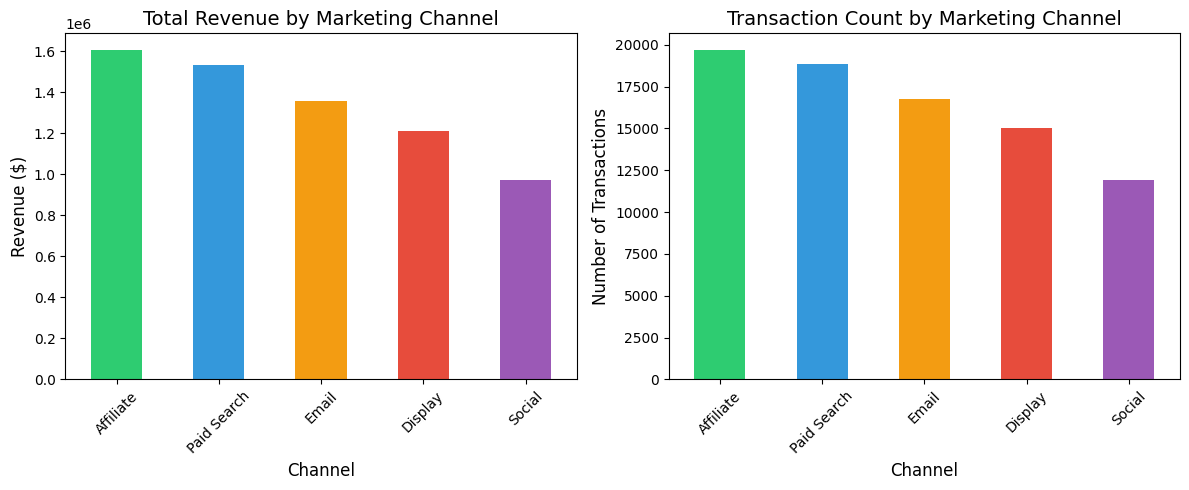

In [ ]:
print("="*60)
print("MARKETING CHANNEL ROI")
print("="*60)

# Merge campaign data with transactions
campaign_performance = transactions.merge(campaigns, on='campaign_id', how='left')

# Calculate revenue and transaction count by channel
channel_performance = campaign_performance.groupby('channel').agg({
    'gross_revenue': ['sum', 'mean', 'count'],
    'transaction_id': 'count'
}).round(2)

channel_performance.columns = ['total_revenue', 'avg_revenue', 'transaction_count', 'total_transactions']
channel_performance = channel_performance.sort_values('total_revenue', ascending=False)

print("\n📊 REVENUE BY MARKETING CHANNEL:")
print(channel_performance)

# Visualization
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#9b59b6']
channel_performance['total_revenue'].plot(kind='bar', color=colors)
plt.title('Total Revenue by Marketing Channel', fontsize=14)
plt.xlabel('Channel', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
channel_performance['transaction_count'].plot(kind='bar', color=colors)
plt.title('Transaction Count by Marketing Channel', fontsize=14)
plt.xlabel('Channel', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

FUNNEL CONVERSION

📊 FUNNEL CONVERSION ANALYSIS:
      stage  sessions  conversion_rate  drop_rate  drop_from_prev
       view    526902       100.000000   0.000000             NaN
add_to_cart    231525        43.940809  56.059191       56.059191
   purchase     95539        18.132214  81.867786       58.734910


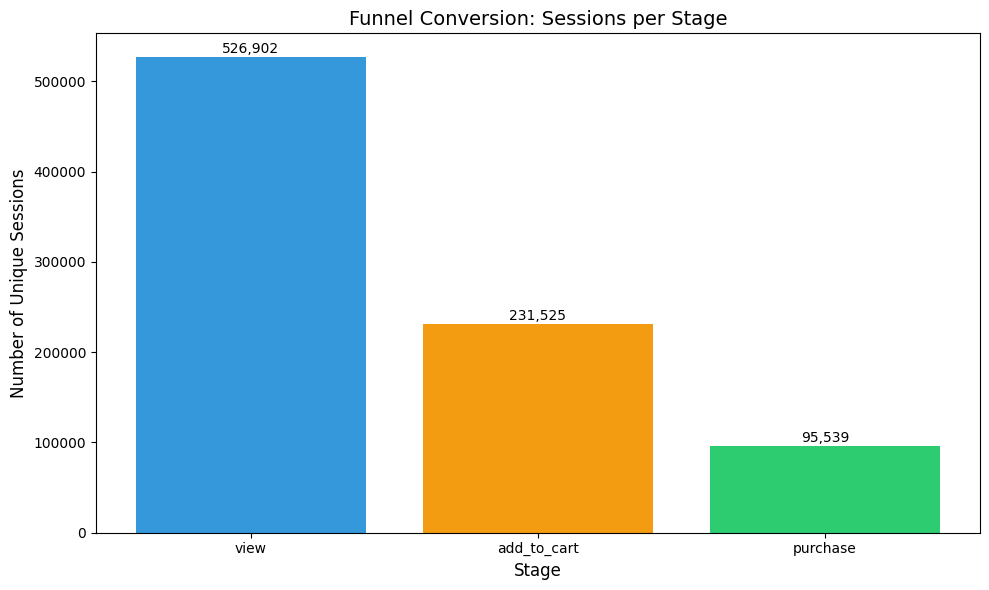


📉 BIGGEST DROP-OFF:
   Stage 'purchase' has drop-off: 58.7%
   Stage 'add_to_cart' has drop-off: 56.1%

   🔴 BIGGEST DROP: 'purchase' with 58.7% loss


In [ ]:
print("="*60)
print("FUNNEL CONVERSION")
print("="*60)

# Define funnel stages
funnel_stages = ['view', 'add_to_cart', 'purchase']

# Count unique sessions per stage
funnel_data = {}
for stage in funnel_stages:
    sessions = events[events['event_type'] == stage]['session_id'].nunique()
    funnel_data[stage] = sessions

# Calculate conversion rates
funnel_df = pd.DataFrame(list(funnel_data.items()), columns=['stage', 'sessions'])
funnel_df['conversion_rate'] = (funnel_df['sessions'] / funnel_df['sessions'].iloc[0]) * 100
funnel_df['drop_rate'] = 100 - funnel_df['conversion_rate']
funnel_df['drop_from_prev'] = funnel_df['sessions'].pct_change() * -100

print("\n📊 FUNNEL CONVERSION ANALYSIS:")
print(funnel_df.to_string(index=False))

# Visualization
plt.figure(figsize=(10, 6))
colors = ['#3498db', '#f39c12', '#2ecc71']
bars = plt.bar(funnel_df['stage'], funnel_df['sessions'], color=colors)
plt.title('Funnel Conversion: Sessions per Stage', fontsize=14)
plt.xlabel('Stage', fontsize=12)
plt.ylabel('Number of Unique Sessions', fontsize=12)

# Add value labels on bars
for bar, value in zip(bars, funnel_df['sessions']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
             f'{value:,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Drop-off analysis (FIXED)
print("\n📉 BIGGEST DROP-OFF:")
if len(funnel_df) >= 3:
    drop_off = funnel_df['drop_from_prev'].iloc[2]
    drop_stage = funnel_df['stage'].iloc[2]
    print(f"   Stage '{drop_stage}' has drop-off: {drop_off:.1f}%")

    # calculate drop from view to add_to_cart
    drop_off_view_to_cart = funnel_df['drop_from_prev'].iloc[1]
    drop_stage_cart = funnel_df['stage'].iloc[1]
    print(f"   Stage '{drop_stage_cart}' has drop-off: {drop_off_view_to_cart:.1f}%")

    # Find biggest drop
    if drop_off > drop_off_view_to_cart:
        print(f"\n   🔴 BIGGEST DROP: '{drop_stage}' with {drop_off:.1f}% loss")
    else:
        print(f"\n   🔴 BIGGEST DROP: '{drop_stage_cart}' with {drop_off_view_to_cart:.1f}% loss")
else:
    print("   Not enough data for drop-off analysis")

A/B TESTING RESULTS

📊 A/B TEST SUMMARY:
event_type        add_to_cart  purchase
experiment_group                       
Control                170912     56855
Variant_A               57100     21045
Variant_B               56358     25227

📊 CONVERSION RATES BY GROUP:
event_type        purchase   total  conversion_rate
experiment_group                                   
Control              56855  227767        24.961913
Variant_A            21045   78145        26.930706
Variant_B            25227   81585        30.921125

📊 STATISTICAL SIGNIFICANCE TEST:
   Chi-square: 1097.2496
   P-value: 0.0000

   ✅ RESULT: Statistically significant at 95% confidence level
   → The difference between experiment groups is REAL, not random


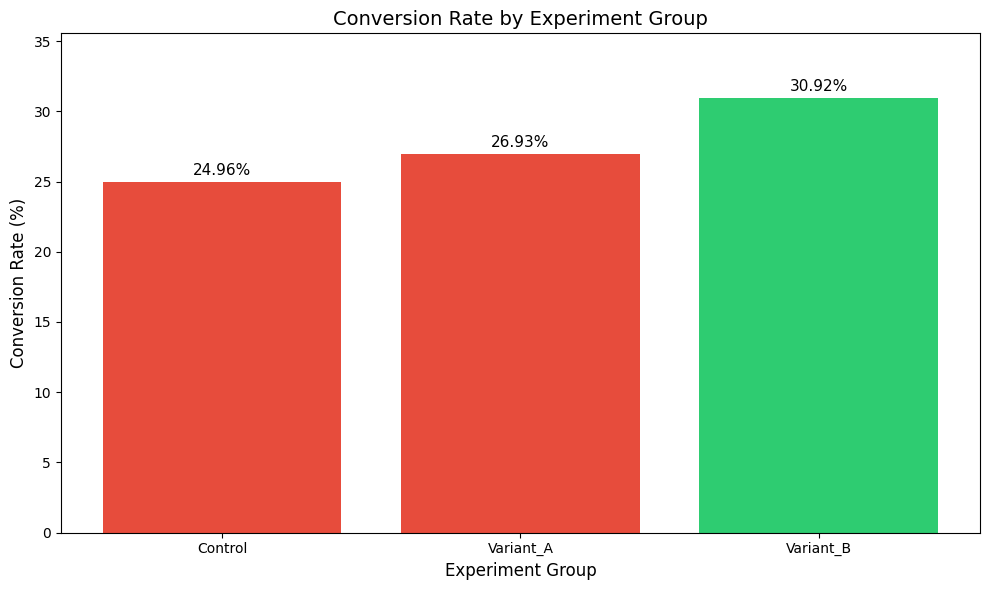

In [ ]:
print("="*60)
print("A/B TESTING RESULTS")
print("="*60)

from scipy.stats import chi2_contingency

# Analyze A/B test impact on purchases
ab_test = events[events['event_type'].isin(['purchase', 'add_to_cart'])]
ab_summary = ab_test.groupby(['experiment_group', 'event_type']).size().unstack(fill_value=0)

print("\n📊 A/B TEST SUMMARY:")
print(ab_summary)

# Calculate conversion rates
if 'purchase' in ab_summary.columns:
    ab_summary['total'] = ab_summary.sum(axis=1)
    ab_summary['conversion_rate'] = (ab_summary['purchase'] / ab_summary['total']) * 100
    print("\n📊 CONVERSION RATES BY GROUP:")
    print(ab_summary[['purchase', 'total', 'conversion_rate']])

# Statistical test
if 'purchase' in ab_summary.columns and len(ab_summary) >= 2:
    contingency = ab_summary[['purchase', 'add_to_cart']].values
    chi2, p_value, dof, expected = chi2_contingency(contingency)

    print("\n📊 STATISTICAL SIGNIFICANCE TEST:")
    print(f"   Chi-square: {chi2:.4f}")
    print(f"   P-value: {p_value:.4f}")

    if p_value < 0.05:
        print(f"\n   ✅ RESULT: Statistically significant at 95% confidence level")
        print(f"   → The difference between experiment groups is REAL, not random")
    else:
        print(f"\n   ⚠️ RESULT: NOT statistically significant")
        print(f"   → The difference could be due to random chance")

# Visualization
plt.figure(figsize=(10, 6))
groups = ab_summary.index
conversion_rates = ab_summary['conversion_rate']
colors = ['#2ecc71' if x == max(conversion_rates) else '#e74c3c' for x in conversion_rates]
plt.bar(groups, conversion_rates, color=colors)
plt.title('Conversion Rate by Experiment Group', fontsize=14)
plt.xlabel('Experiment Group', fontsize=12)
plt.ylabel('Conversion Rate (%)', fontsize=12)
for i, (group, rate) in enumerate(zip(groups, conversion_rates)):
    plt.text(i, rate + 0.5, f'{rate:.2f}%', ha='center', fontsize=11)
plt.ylim(0, max(conversion_rates) * 1.15)
plt.tight_layout()
plt.show()

In [ ]:
# Export Marketing Channel ROI
channel_export = channel_performance.reset_index()
channel_export.to_csv('marketing_channel_roi.csv', index=False)
print("✅ marketing_channel_roi.csv siap download")

# Export Funnel Data
funnel_export = funnel_df[['stage', 'sessions']]
funnel_export.to_csv('funnel_data.csv', index=False)
print("✅ funnel_data.csv siap download")

# Export A/B Testing Data
ab_export = ab_summary.reset_index()
ab_export.to_csv('ab_testing_results.csv', index=False)
print("✅ ab_testing_results.csv siap download")

print("\n📁 3 files ready for Tableau:")
print("   - marketing_channel_roi.csv")
print("   - funnel_data.csv")
print("   - ab_testing_results.csv")

✅ marketing_channel_roi.csv siap download
✅ funnel_data.csv siap download
✅ ab_testing_results.csv siap download

📁 3 files ready for Tableau:
   - marketing_channel_roi.csv
   - funnel_data.csv
   - ab_testing_results.csv
